# BNS GRB Classification

Classifying Binary Neutron Star mergers from the COMPAS fiducial population (Model A) using the [Gottlieb et al. (2023)](https://arxiv.org/abs/2309.00038) hybrid scenario.

**Classification rules (BNS):**
- `M_tot < 2.8 M☉` → Short cbGRB (HMNS collapse)
- `M_tot ≥ 2.8 M☉` and `q < 1.2` → Short cbGRB (BH + light disk)
- `M_tot ≥ 2.8 M☉` and `q ≥ 1.2` → Long cbGRB (BH + massive disk, GW211211A-like)

**Data:** COMPAS fiducial BNS simulation — [Zenodo 5189849](https://zenodo.org/records/5189849)

## 1. Load Data

In [18]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt

path = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'

fdata = h5.File(path, 'r')
fDCO  = fdata['doubleCompactObjects']

mass1               = fDCO['M1'][...].squeeze()
mass2               = fDCO['M2'][...].squeeze()
weights             = fDCO['weight'][...].squeeze()
metallicitySystems  = fDCO['Metallicity1'][...].squeeze()
mergesInHubbleTime  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
tc                  = fDCO['tc'][...].squeeze()
tform               = fDCO['tform'][...].squeeze()
m1zams              = fDCO['M1ZAMS'][...].squeeze()
m2zams              = fDCO['M2ZAMS'][...].squeeze()

## 2. Gottlieb GRB Classification

Compute total mass `M_tot` and mass ratio `q` for all merging BNS systems, then assign a GRB class following the hybrid scenario.

In [19]:
mask_merging = (mergesInHubbleTime == 1)

M_tot = mass1[mask_merging] + mass2[mask_merging]
q     = np.maximum(mass1[mask_merging], mass2[mask_merging]) / \
        np.minimum(mass1[mask_merging], mass2[mask_merging])

M_crit = 2.8

short_cbGRB = (M_tot < M_crit) | ((M_tot >= M_crit) & (q < 1.2))
long_cbGRB  = (M_tot >= M_crit) & (q >= 1.2)

### Sanity Check

In [20]:
n_merging   = mask_merging.sum()
n_short     = short_cbGRB.sum()
n_long      = long_cbGRB.sum()

print(f"Total BNS systems:       {len(mass1):,}")
print(f"Merging in Hubble time:  {n_merging:,}  ({100*n_merging/len(mass1):.1f}%)")
print(f"Short cbGRB:             {n_short:,}  ({100*n_short/n_merging:.1f}%)")
print(f"Long cbGRB:              {n_long:,}  ({100*n_long/n_merging:.1f}%)")
print(f"\nM_tot range: {M_tot.min():.2f} – {M_tot.max():.2f} M☉")
print(f"q range:     {q.min():.2f} – {q.max():.2f}")

Total BNS systems:       233,137
Merging in Hubble time:  233,137  (100.0%)
Short cbGRB:             189,855  (81.4%)
Long cbGRB:              43,282  (18.6%)

M_tot range: 2.54 – 4.96 M☉
q range:     1.00 – 1.96


## 3. M₁ vs M₂ Mass Plane

Scatter plot of compact object masses colored by GRB class.

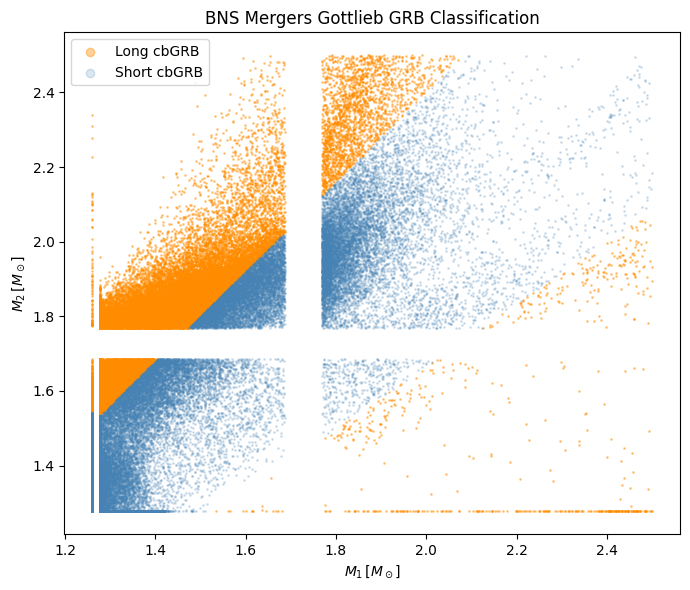

In [21]:
w = weights[mask_merging]

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(mass1[mask_merging][long_cbGRB],  mass2[mask_merging][long_cbGRB],
           s=1, alpha=0.4, color='darkorange', label='Long cbGRB')
ax.scatter(mass1[mask_merging][short_cbGRB], mass2[mask_merging][short_cbGRB],
           s=1, alpha=0.2, color='steelblue',  label='Short cbGRB')

ax.set_xlabel(r'$M_1 \, [M_\odot]$')
ax.set_ylabel(r'$M_2 \, [M_\odot]$')
ax.set_title('BNS Mergers Gottlieb GRB Classification')
ax.legend(markerscale=6)
plt.tight_layout()
plt.show()

## 4. Formation Efficiency vs Metallicity

Formation efficiency = number of mergers per solar mass of star-forming material. Computed at each of the 53 metallicity grid points using STROOPWAFEL sampling weights.

In [22]:
metallicityGrid = [0.0001, 0.00011, 0.00012, 0.00014, 0.00016, 0.00017,
                   0.00019, 0.00022, 0.00024, 0.00027, 0.0003,  0.00034,
                   0.00037, 0.00042, 0.00047, 0.00052, 0.00058, 0.00065,
                   0.00073, 0.00081, 0.0009,  0.00101, 0.00113, 0.00126,
                   0.0014,  0.00157, 0.00175, 0.00195, 0.00218, 0.00243,
                   0.00272, 0.00303, 0.00339, 0.00378, 0.00422, 0.00471,
                   0.00526, 0.00587, 0.00655, 0.00732, 0.00817, 0.00912,
                   0.01018, 0.01137, 0.01269, 0.01416, 0.01581, 0.01765,
                   0.01971, 0.022,   0.0244,  0.02705, 0.03]

meanMassEvolved = 77708655  # avg stellar mass per metallicity simulation

Z_all   = metallicitySystems[mask_merging]
w_all   = weights[mask_merging]

eff_total = np.zeros(len(metallicityGrid))
eff_short = np.zeros(len(metallicityGrid))
eff_long  = np.zeros(len(metallicityGrid))

unique_Z = np.unique(metallicitySystems)

for i, Z in enumerate(metallicityGrid):
    if Z in unique_Z:
        maskZ = (Z_all == Z)
        eff_total[i] = np.sum(w_all[maskZ])                    / meanMassEvolved
        eff_short[i] = np.sum(w_all[maskZ & short_cbGRB])      / meanMassEvolved
        eff_long[i]  = np.sum(w_all[maskZ & long_cbGRB])       / meanMassEvolved

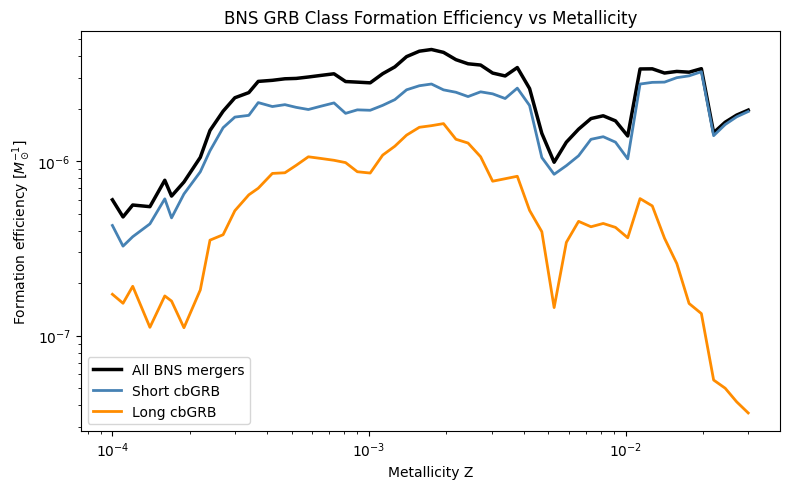

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(metallicityGrid, eff_total, color='black',      lw=2.5, label='All BNS mergers')
ax.plot(metallicityGrid, eff_short, color='steelblue',  lw=2,   label='Short cbGRB')
ax.plot(metallicityGrid, eff_long,  color='darkorange', lw=2,   label='Long cbGRB')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Metallicity Z')
ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$')
ax.set_title('BNS GRB Class Formation Efficiency vs Metallicity')
ax.legend()
plt.tight_layout()
plt.show()

### GRB Class Fraction vs Metallicity

Fraction of BNS mergers in each GRB class as a function of birth metallicity.

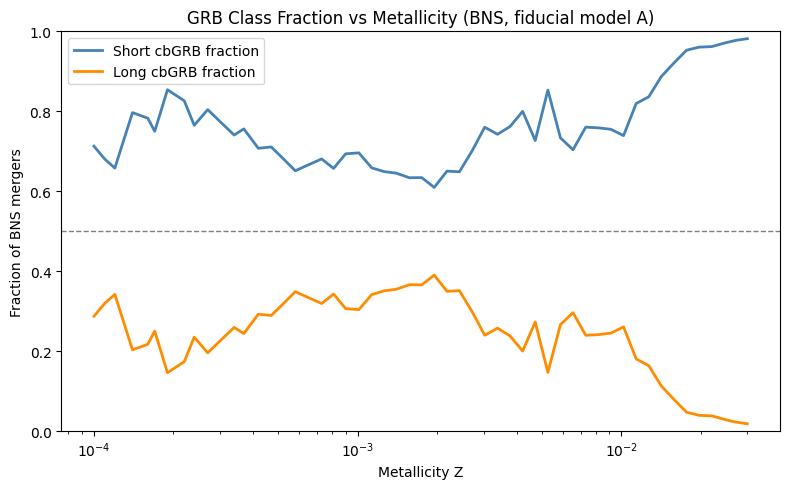

In [24]:
# metallicities with no systems
with np.errstate(invalid='ignore', divide='ignore'):
    frac_long  = np.where(eff_total > 0, eff_long  / eff_total, np.nan)
    frac_short = np.where(eff_total > 0, eff_short / eff_total, np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(metallicityGrid, frac_short, color='steelblue',  lw=2, label='Short cbGRB fraction')
ax.plot(metallicityGrid, frac_long,  color='darkorange', lw=2, label='Long cbGRB fraction')
ax.axhline(0.5, color='gray', lw=1, ls='--')
ax.set_xscale('log')
ax.set_ylim(0, 1)
ax.set_xlabel('Metallicity Z')
ax.set_ylabel('Fraction of BNS mergers')
ax.set_title('GRB Class Fraction vs Metallicity (BNS, fiducial model A)')
ax.legend()
plt.tight_layout()
plt.show()

### Delay Time Distribution

Total delay time = stellar evolution time + coalescence time.

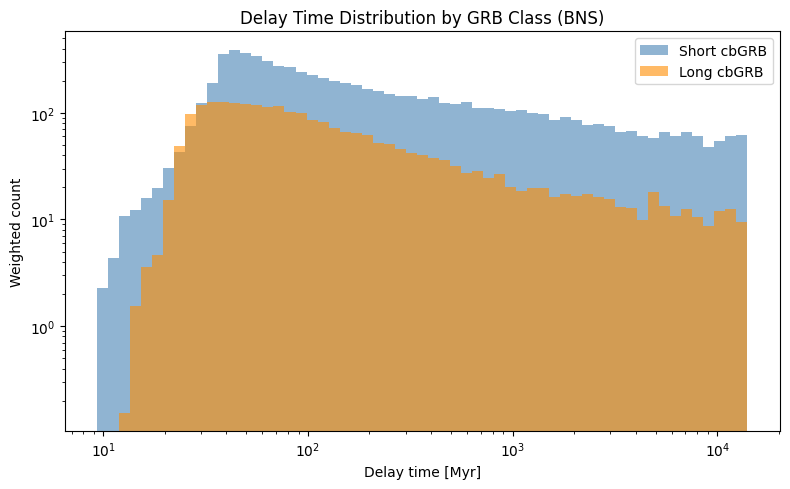

In [25]:
delay_times = (tform + tc)[mask_merging]  # total delay time in Myr

bins = np.logspace(np.log10(delay_times.min()+1), np.log10(delay_times.max()), 60)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(delay_times[short_cbGRB], bins=bins, weights=weights[mask_merging][short_cbGRB],
        color='steelblue', alpha=0.6, label='Short cbGRB')
ax.hist(delay_times[long_cbGRB],  bins=bins, weights=weights[mask_merging][long_cbGRB],
        color='darkorange', alpha=0.6, label='Long cbGRB')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Delay time [Myr]')
ax.set_ylabel('Weighted count')
ax.set_title('Delay Time Distribution by GRB Class (BNS)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Model Comparison: A vs K

Model K uses a different binary physics prescription. Comparing the two shows robustness of the GRB classification results.

In [26]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'

fdata_K = h5.File(path_K, 'r')
fDCO_K  = fdata_K['doubleCompactObjects']

mass1_K              = fDCO_K['M1'][...].squeeze()
mass2_K              = fDCO_K['M2'][...].squeeze()
weights_K            = fDCO_K['weight'][...].squeeze()
metallicity_K        = fDCO_K['Metallicity1'][...].squeeze()
merges_K             = fDCO_K['mergesInHubbleTimeFlag'][...].squeeze()
tc_K                 = fDCO_K['tc'][...].squeeze()
tform_K              = fDCO_K['tform'][...].squeeze()

mask_K   = (merges_K == 1)
M_tot_K  = mass1_K[mask_K] + mass2_K[mask_K]
q_K      = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / \
           np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K  = (M_tot_K < M_crit) | ((M_tot_K >= M_crit) & (q_K < 1.2))
long_K   = (M_tot_K >= M_crit) & (q_K >= 1.2)

print(f"Model K — Short cbGRB: {short_K.sum():,} ({100*short_K.sum()/mask_K.sum():.1f}%)")
print(f"Model K — Long cbGRB:  {long_K.sum():,}  ({100*long_K.sum()/mask_K.sum():.1f}%)")

Model K — Short cbGRB: 191,290 (81.4%)
Model K — Long cbGRB:  43,673  (18.6%)


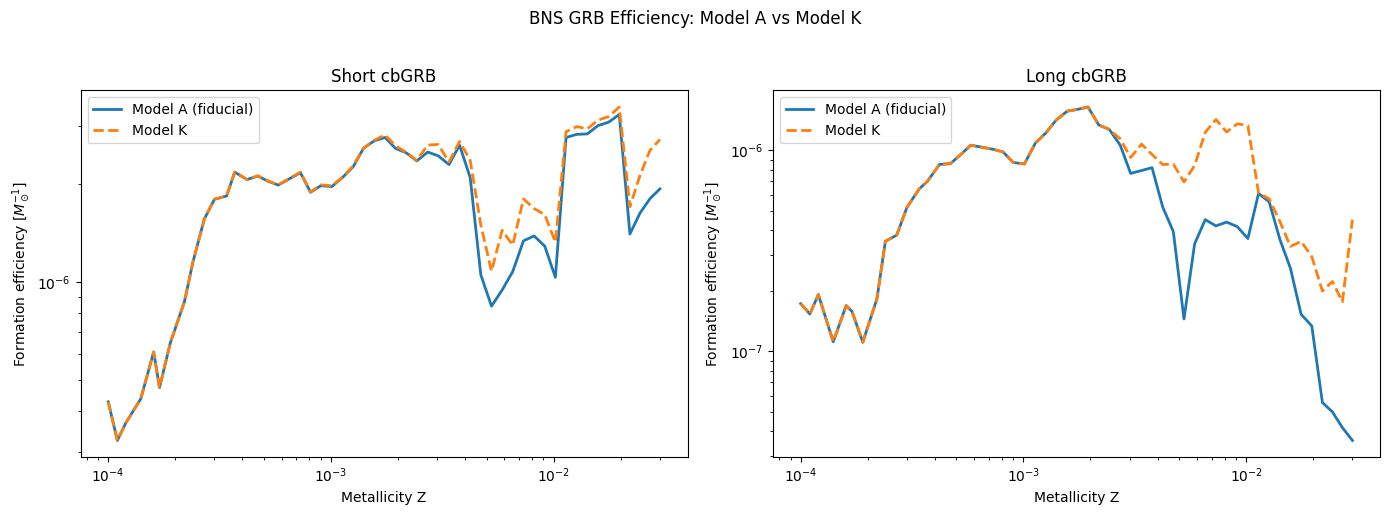

In [27]:
Z_K = metallicity_K[mask_K]
w_K = weights_K[mask_K]
unique_ZK = np.unique(metallicity_K)

eff_total_K = np.zeros(len(metallicityGrid))
eff_short_K = np.zeros(len(metallicityGrid))
eff_long_K  = np.zeros(len(metallicityGrid))

for i, Z in enumerate(metallicityGrid):
    if Z in unique_ZK:
        maskZ = (Z_K == Z)
        eff_total_K[i] = np.sum(w_K[maskZ])               / meanMassEvolved
        eff_short_K[i] = np.sum(w_K[maskZ & short_K])     / meanMassEvolved
        eff_long_K[i]  = np.sum(w_K[maskZ & long_K])      / meanMassEvolved

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, eff_A, eff_B, label in [
    (axes[0], eff_short, eff_short_K, 'Short cbGRB'),
    (axes[1], eff_long,  eff_long_K,  'Long cbGRB')
]:
    ax.plot(metallicityGrid, eff_A, lw=2, label='Model A (fiducial)')
    ax.plot(metallicityGrid, eff_B, lw=2, ls='--', label='Model K')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Metallicity Z')
    ax.set_ylabel(r'Formation efficiency $[M_\odot^{-1}]$')
    ax.set_title(label)
    ax.legend()

plt.suptitle('BNS GRB Efficiency: Model A vs Model K', y=1.02)
plt.tight_layout()
plt.show()

## 6. Uncertainty Analysis

Sensitivity of the GRB class fractions to the two free classification parameters.

### 6a. M_crit Sensitivity (NS Equation of State)

Vary the critical total mass `M_crit` from 2.6–3.0 M☉ to probe EOS uncertainty.

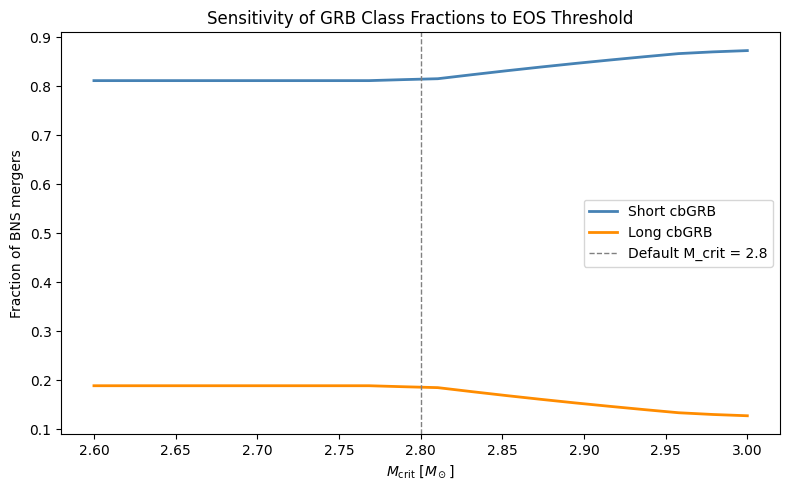

In [28]:
M_crit_range = np.linspace(2.6, 3.0, 20)
frac_long_vs_Mcrit  = []
frac_short_vs_Mcrit = []

for Mc in M_crit_range:
    s = (M_tot < Mc) | ((M_tot >= Mc) & (q < 1.2))
    l = (M_tot >= Mc) & (q >= 1.2)
    n = len(M_tot)
    frac_short_vs_Mcrit.append(s.sum() / n)
    frac_long_vs_Mcrit.append(l.sum() / n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(M_crit_range, frac_short_vs_Mcrit, color='steelblue',  lw=2, label='Short cbGRB')
ax.plot(M_crit_range, frac_long_vs_Mcrit,  color='darkorange', lw=2, label='Long cbGRB')
ax.axvline(2.8, color='gray', ls='--', lw=1, label='Default M_crit = 2.8')
ax.set_xlabel(r'$M_\mathrm{crit}$ [$M_\odot$]')
ax.set_ylabel('Fraction of BNS mergers')
ax.set_title('Sensitivity of GRB Class Fractions to EOS Threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 6b. Mass Ratio Threshold Sensitivity

Vary the `q = 1.2` boundary that separates short from long cbGRB.

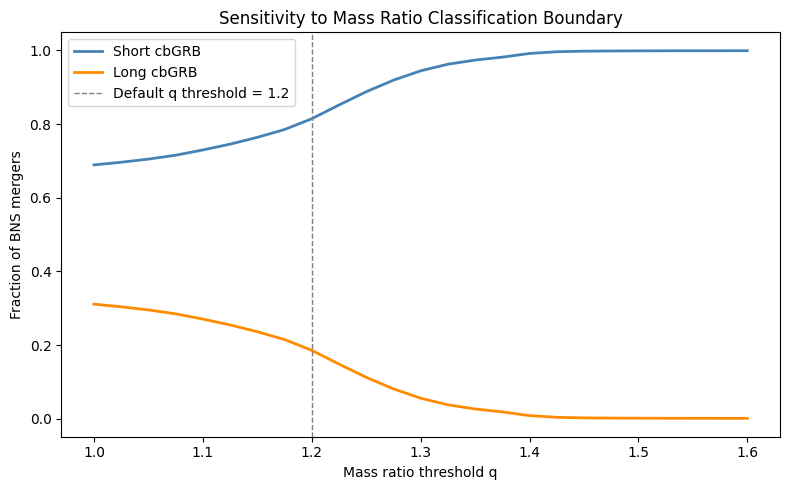

In [29]:
q_thresh_range = np.linspace(1.0, 1.6, 25)
frac_long_q  = []
frac_short_q = []

for qt in q_thresh_range:
    s = (M_tot < M_crit) | ((M_tot >= M_crit) & (q < qt))
    l = (M_tot >= M_crit) & (q >= qt)
    frac_short_q.append(s.sum() / len(M_tot))
    frac_long_q.append(l.sum()  / len(M_tot))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q_thresh_range, frac_short_q, color='steelblue',  lw=2, label='Short cbGRB')
ax.plot(q_thresh_range, frac_long_q,  color='darkorange', lw=2, label='Long cbGRB')
ax.axvline(1.2, color='gray', ls='--', lw=1, label='Default q threshold = 1.2')
ax.set_xlabel('Mass ratio threshold q')
ax.set_ylabel('Fraction of BNS mergers')
ax.set_title('Sensitivity to Mass Ratio Classification Boundary')
ax.legend()
plt.tight_layout()
plt.show()

### 6c. Mass Ratio Distribution

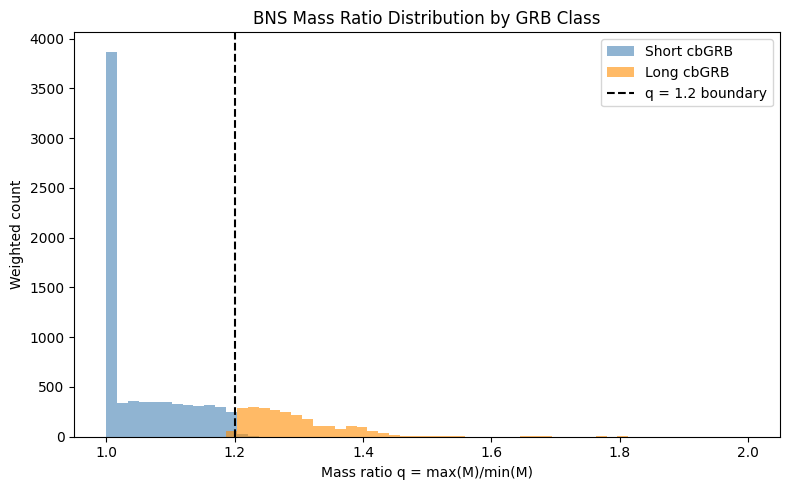

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(1.0, 2.0, 60)

ax.hist(q[short_cbGRB], bins=bins, weights=weights[mask_merging][short_cbGRB],
        color='steelblue', alpha=0.6, label='Short cbGRB')
ax.hist(q[long_cbGRB],  bins=bins, weights=weights[mask_merging][long_cbGRB],
        color='darkorange', alpha=0.6, label='Long cbGRB')
ax.axvline(1.2, color='black', ls='--', lw=1.5, label='q = 1.2 boundary')
ax.set_xlabel('Mass ratio q = max(M)/min(M)')
ax.set_ylabel('Weighted count')
ax.set_title('BNS Mass Ratio Distribution by GRB Class')
ax.legend()
plt.tight_layout()
plt.show()

### 6d. Progenitor ZAMS Mass Plane

Which zero-age main sequence stellar systems produce each GRB class?

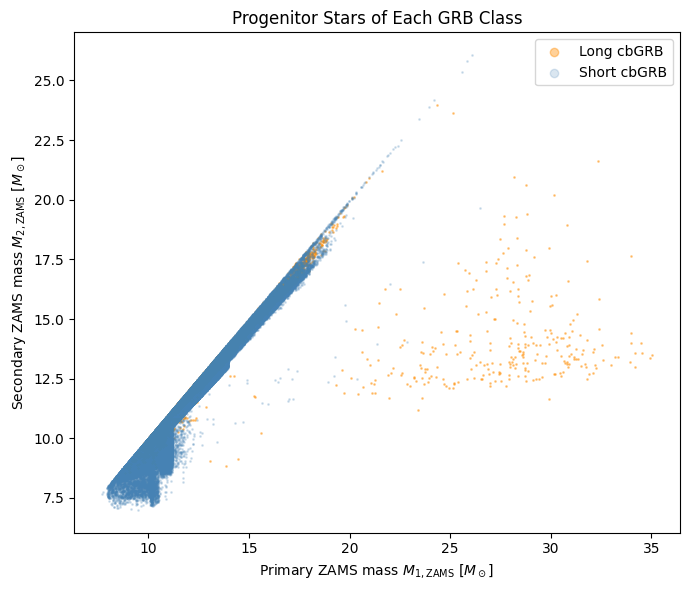

In [31]:
m1zams_merging = m1zams[mask_merging]
m2zams_merging = m2zams[mask_merging]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(m1zams_merging[long_cbGRB],  m2zams_merging[long_cbGRB],
           s=1, alpha=0.4, color='darkorange', label='Long cbGRB')
ax.scatter(m1zams_merging[short_cbGRB], m2zams_merging[short_cbGRB],
           s=1, alpha=0.2, color='steelblue',  label='Short cbGRB')
ax.set_xlabel(r'Primary ZAMS mass $M_{1,\rm ZAMS}$ [$M_\odot$]')
ax.set_ylabel(r'Secondary ZAMS mass $M_{2,\rm ZAMS}$ [$M_\odot$]')
ax.set_title('Progenitor Stars of Each GRB Class')
ax.legend(markerscale=6)
plt.tight_layout()
plt.show()

## Export

Save formation efficiency arrays for use in the comparison notebook.

In [32]:
import numpy as np
np.save('/Users/josephrodriguez/research visualization/eff_BNS.npy', 
        np.array([eff_total, eff_short, eff_long]))
print("BNS efficiencies saved.")

BNS efficiencies saved.
